## Libraries

In [1]:
# Use this cell to regroup all your imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from tempfile import mkdtemp
from shutil import rmtree

from xgboost import XGBRegressor

from sklearn import set_config
set_config(display = 'diagram')

# Sklearn preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.ensemble import AdaBoostRegressor, VotingRegressor, GradientBoostingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold, SelectFromModel
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# 🏆 Kaggle batch competition

**Welcome to your first Kaggle competition!**

<img src='https://d32aokrjazspmn.cloudfront.net/materials/kaggle-batch-challenge.png' width=600>

Your goal is to **submit an online prediction** for the open competition [House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) 🏠

You have already worked with a housing dataset in the bootcamp! This exercise will be **semi-guided** so you can build a **baseline model**, and after that you are free to improve and iterate on it. We will tackle the problem using **pipelines** (best practice)!

A few words about Kaggle:
- Kaggle ranks your submissions among all participants!
- Everyone is removed from the public leaderboard after 2 months
- You can submit up to 10 times per day

🧹 Today is a great day to practice keeping your long notebook **tidy** 🧹
- Collapse all headings from the command palette (`Cmd + Shift + P`)
- Stay **idempotent** (`Restart & Run All` should never crash)
- Name and delete variables carefully


## Kaggle setup

👉 Create an account on Kaggle if you want to join the competition

👉 Join the [House Prices Challenge](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) competition


## Loading data

In the competition instructions you should already have run the steps to download everything you need from Kaggle into your notebook folder:

- `train.csv` is your training set `(1460, 81)` with your `X` and `y`
- `test.csv` is your test set `(1459, 80)` without the target `y` 😈
- `sample_submission.csv` describes the format required for your submission

ℹ️ You will find a detailed description of the dataset [here](https://d32aokrjazspmn.cloudfront.net/materials/kaggle_houses_data_description.txt). Refer to it throughout the competition!

Your goal is to predict the missing `y_pred` on the test set and submit to discover your `test_score` and rank

❓ Load the training data into a DataFrame named `data` and build your `X` and `y`. Inspect their shapes.

**Tip:** If you inspect the CSV, you will notice a column named `Id`. When reading the CSV into a DataFrame, make sure you set `index_col="Id"` so you do not end up with two ID columns 😉


In [14]:
data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/houses_train_raw.csv", index_col="Id")
X = data.drop(columns=["SalePrice"])
y = data["SalePrice"]

X.shape, y.shape


((1460, 79), (1460,))

# 🐣 1. BASELINE

## 1.1 First feature overview

79 features is too many to handle one by one for the first baseline pipeline! Let us handle them only by their `dtype`s:

❓ How many numerical features and how many categorical features do we have?


In [15]:
X.dtypes.value_counts()

object     43
int64      33
float64     3
Name: count, dtype: int64

❓ Build a Series named `feat_categorical_nunique` with the **number of unique values** for each categorical feature in the training set. How many unique categories in total?


In [16]:
feat_categorical_nunique = X.select_dtypes(include='object').nunique()
feat_categorical_nunique.sum()

251

🤔 If we `OneHotEncode` all categorical features, our feature matrix `X_preproc` becomes quite large and sparse with almost 300 (highly correlated) features for only ~1400 observations. Ideally we should aim to feed the model at most ~50 features (📚 read this [practical rule](https://datascience.stackexchange.com/a/11480/98300))

We know two main strategies to reduce the number of categorical features after preprocessing:
1. **[Drop](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.feature_selection)** features that add little explanatory power to our model; this may require statistical analysis of feature importance
2. **[Ordinal encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html)** (instead of one-hot) maps categorical features to integers; but that introduces a notion of "order" (1 > 2 > 3 > ...) which can hurt if not handled properly!


❓ Plot a **histogram** of the number of unique values per categorical feature. Do you see quick wins?


<Axes: >

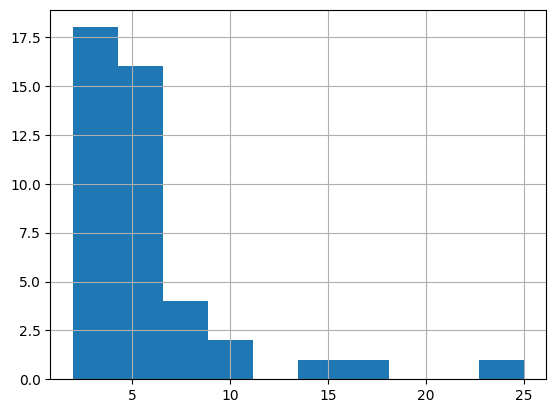

In [17]:
feat_categorical_nunique.hist()

💡 As a starting point, how about simply **dropping** all features with **7 or more unique values** and one-hot encoding the rest? Let us save ordinal encoding and statistical feature selection for the next iteration of our pipeline.

❓ Store the names of the features to OHE in the list `feat_categorical_small` below. How many features will be OHE?


In [ ]:
feat_categorical_small = list(feat_categorical_nunique[feat_categorical_nunique < 7].index)

In [19]:
len(feat_categorical_small)

34

🧪 Test your code below (and clear the cell after it passes)


In [20]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'features_overview',
    n=len(feat_categorical_small)
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/kaggle-competition/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_features_overview.py::TestFeaturesOverview::test_feat_categorical_small PASSED [100%]

============================== 1 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/features_overview.pickle

git commit -m 'Completed features_overview step'

git push origin master



## 1.2 Baseline pipeline

### a) Preprocessing

❓ Let us code the basic preprocessing pipeline described below. Save it as `preproc_baseline`.

For categorical features:
- SimpleImpute with the most frequent values
- One-hot encode features that initially have fewer than 7 unique values
- Drop all other categorical features


For numerical features:
- SimpleImpute with `mean` strategy
- Min-Max scaling


<details>
    <summary>ℹ️ Click here for a pro tip</summary>

If you feel confident, you can try sklearn's shorter syntax `make_pipeline` or `make_column_transformer` instead of the longer `Pipeline` or `ColumnTransformer` syntax; it is also handy if you want to avoid manually naming each step.
</details>


In [ ]:
# YOUR CODE HERE

❓ Look at the **shape** of your preprocessed DataFrame and save it in `shape_preproc_baseline`


In [ ]:
# YOUR CODE HERE

🧪 Test your code below


In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult(
    'preproc_baseline',
    shape=shape_preproc_baseline
)

result.write()
print(result.check())

### b) Add an estimator

❓ Add a simple Decision Tree model to `preproc_baseline` and store it in the variable `pipe_baseline`.


In [ ]:
# YOUR CODE HERE

### c) Cross-validation

❓ Read the Kaggle [competition evaluation rules](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview/evaluation). Which performance metric do you need? Is it available out of the box in sklearn?

Unfortunately not! We will need to build a custom `sklearn.metrics.scorer` before any cross-validation or grid search. The procedure is described below:


1. Using [`make_scorer`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html), create a scorer named `rmsle` that can be passed as the `scoring` `kwarg`:
    ```python
    cross_val_score(pipe_baseline, X, y, cv=5, scoring=rmsle)
    ```
2. Create `rmsle_neg`, the negated version so that _higher is better_; this will be useful later because `GridSearchCV` always tries to _maximize_ the score 😉
    ```python
    GridSearchCV(pipe_baseline, param_grid=..., cv=5, scoring=rmsle_neg)
    ```


RMSLE formula

$$\text{RMSLE}(y, \hat{y}) = \sqrt{\frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (\log_e (1 + y_i) - \log_e (1 + \hat{y}_i) )^2.}$$


In [ ]:
# YOUR CODE HERE

❓ Run 5-fold cross-validation on your `pipe_baseline` using this metric for a first look at baseline performance.    

Store the mean score as `score_baseline`


In [ ]:
# YOUR CODE HERE

### d) Baseline prediction

❓ Predict `y_pred_baseline` from the Kaggle `test.csv` dataset you saved in the `data` folder.


In [ ]:
X_test = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/houses_test_raw.csv")
X_test_ids = X_test['Id'] # Keep ids
X_test = X_test.drop(columns=['Id'])

# Predict y_pred_baseline
pass  # YOUR CODE HERE

❓ Finally, save your submission-ready CSV as `submission_baseline.csv` in the `data` folder. **Read** Kaggle's required format carefully, understand it, and test below (you do not need to submit this baseline to Kaggle for now).


In [ ]:
results = pd.concat([X_test_ids, pd.Series(y_pred_baseline, name="SalePrice")], axis=1)
results.head(1)

In [ ]:
# Export to Kaggle format submission in the `data` folder
results.to_csv("data/submission_baseline.csv", header=True, index=False)

🧪 Test your code


In [ ]:
from nbresult import ChallengeResult

tmp = pd.read_csv("data/submission_baseline.csv")

result = ChallengeResult(
    'submission_baseline',
    score_baseline = score_baseline,
    submission_shape = tmp.shape,
    submission_columns = list(tmp.columns),
    submission_dtypes = str(list(tmp.dtypes)),
)

result.write()
print(result.check())

# 🏋️‍♀️ 2. ITERATIONS 

🎉 🎉 Congratulations on building a baseline model with a full pipeline! You will now see how easy it is to iterate and improve performance 🚀

Your goal now is to improve your prediction and **submit to Kaggle at least 30 minutes before the Recap** ⏳

Below are some suggestions for improvements: **pick your battles** and improve your pipeline **incrementally** as you see fit!

**Estimators**

- Tree-based ensembles (definitely try today); often the best fit for problems with many categorical features
- Stacking!
- XGBoost!

**Preprocessing** (after your first ensemble model runs)

- **Ordinal encoding** of categorical features that have a natural order (e.g. "poor", "average", "good")
- **Statistical feature selection** to drop redundant features (reduces overfitting and training time)
- Predict `log(SalePrice)` instead of `SalePrice`?
- 🤷


## 2.1 Preprocessing iteration ♲ 
**⚠️ Come back here after you iterate on estimators in section 2.2 ⚠️**

⏩ Collapse me if I am not in use!


### a) Ordinal encoding (~1s)

❓ Look at the feature below. Could it not be encoded numerically in a sensible way?
```
ExterQual: Evaluates the quality of the material on the exterior
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
```

💡 Luckily, `OrdinalEncoder` with the `categories` argument lets us do exactly that! Check below and make sure you understand how it works 👇


In [ ]:
# Define specific order for features
# Note: if you change this order, it will change the output for .transform()
feature_A_sorted_values = ['bad', 'average', 'good']
feature_B_sorted_values = ['dirty', 'clean', 'new']

encoder = OrdinalEncoder(
    categories=[
        feature_A_sorted_values,
        feature_B_sorted_values
    ],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Just some random training data
XX = [
    ['good', 'dirty'],
    ['bad', 'new'],
    ['average', 'clean'],
]

encoder.fit(XX)

encoder.transform([
        ['bad', "dirty"],
        ["average", "clean"],
        ['good', 'new'],
        ['bad', 'oops never seen this label before']
])

❓ **Your turn**: split your categorical preprocessor into

- `preproc_ordinal` to ordinally encode **some features** (your choice)
- `preproc_nominal` to one-hot encode the others


<details>
    <summary>Hints</summary>

- You will not avoid hard-coding feature names and ordered values! Stay organized!
- Sorting your features alphabetically is good practice to avoid nasty surprises
</details>


In [ ]:
# YOUR CODE HERE

### b) Statistical feature selection (~30min)

Our goal is to drop the least informative features to limit overfitting and shorten training time.  

🔥 We will use sklearn's [feature selection](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.feature_selection) transformers directly in your pipeline!

❗️ To get started, we recommend you try **only Option 1** today. Options 2 and 3 will be addressed in the Recap!


#### Option 1 (Recommended) - <font color=green>Univariate</font> feature selection
*based on mutual information with target `y`*

- Do not hesitate to add a `SelectPercentile` filter at the end of your `preproc` pipeline.
- That will filter out features that explain the target the least when taken individually!
- The statistical test we suggest passing to SelectPercentile is `mutual_info_regression`

<details>
    <summary markdown='span'>🤔 What is mutual information? Click here!</summary>

- [Mutual information](https://en.wikipedia.org/wiki/Mutual_information) is a **statistical** distance between two probability distributions
- Correlation is a **linear** relationship between two random variables
- Mutual information is more general and measures how much uncertainty in Y is reduced after observing X.
- On the other hand, if you already know you are working with well-behaved variables (e.g. continuous numerical), correlation can sometimes tell you more about them, for example when relationships are monotonic.

See [this animation](https://twitter.com/ari_seff/status/1409296508634152964)
</details>


In [ ]:
# YOUR CODE HERE

#### Option 2 - <font color=green>Multivariate</font> feature selection
*based on joint relationships with target `y`*

🤔 We want to drop features that do not help predict the target even when combined with others.

1️⃣ Remember that you can use [`permutation_importance`](https://scikit-learn.org/stable/modules/permutation_importance.html) together with an estimator! It trains a pipeline per feature and estimates which feature, when randomly shuffled, *hurts* our performance score the most. Those will be the most important features we do not want to remove.

The nice thing is that `scikit-learn` lets you plug this methodology straight into your `preproc` pipeline via the [`SequentialFeatureSelector`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html) transformer, which will recursively drop the least important features according to `cross_val_score`.

However, with many features this can take an extremely long time to train.

2️⃣ Alternatively, a faster route is to use models that already expose some `feature_importance` when fitted. For example, trees with Gini-based `feature_importance_` or Lasso with L1 `coef_`. `scikit-learn` has [`SelectFromModel`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFromModel.html) for exactly that.


In [ ]:
# YOUR CODE HERE

#### Option 3 - <font color=green>Unsupervised</font> selection?
*filter based only on properties of `X`*


❓ A quick win is to drop features with the lowest variance. Think: a feature with only one value is useless (and has zero variance).

Do not hesitate to add a [`VarianceThreshold`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html) at the end of your pipeline!


In [ ]:
# YOUR CODE HERE

❓ Additionally, we can check correlation among **numerical features only**

- Use a heatmap with [Pearson correlation](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) to visually check whether any **numerical** feature is almost perfectly correlated with others
- Use `VIF` from `statsmodels` to inspect features with the strongest multicollinearity


In [ ]:
# YOUR CODE HERE

❓ For **ordinal features**, we can use [Spearman rank correlation](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient) instead to check whether some **ordinally encoded** features are ranked almost the same as others. Feel free to draw another heatmap.


In [ ]:
# YOUR CODE HERE

❓ Now, do not hesitate to build a "filter" in your pipeline that drops any feature beyond a chosen (Spearman + Pearson) correlation threshold; you will need a custom transformer class.


In [ ]:
# YOUR CODE HERE

### c) Handle cyclical features

❓ We have time-based features—why not **transform** them into cyclical features?

🔎 If you want more on why and how we do this, go back to the `Preprocessing Workflow` challenge in the `Prepare the dataset` unit.


In [ ]:
# YOUR CODE HERE

### d) Target engineering (~15min)

❓ We are asked to minimize RMS**L**E. Why not transform to predict the `log` of our target directly?
- Inspect the histogram of target `y`
- Variables that are closer to normally distributed should be easier to predict with linear or parametric models
- Build `y_log` and your new performance metrics
- Do not forget to exponentiate your predictions at the end!


In [ ]:
# YOUR CODE HERE

## 2.2 Model iteration ♻

#### a) Latest version of the preprocessing pipeline
❓ We suggest you start below with a fresh definition of your preprocessing pipeline. Copy-paste from your existing code above.

That way you can update quickly and then try many model types to find the best one. You can try GridSearch (this can take a long time) or go model by model.

You can try one or more of the different models you learned in previous units and today. 

👉 Your goals:

  - **Try at least one linear model**
  
  - **Try at least one tree-based model you discovered in this unit**.

  - Compare **cross-validation** scores across different models.

  - It is also interesting to compare **how long** cross-validation takes for different models. 🔎 Add the `%%time` magic on the first line of a notebook cell to time its execution.


In [ ]:
# YOUR CODE HERE

# 🏅 SUBMISSION 

Time to discover your real test score by submitting to Kaggle! 

👉 Follow and complete the next steps to see how well your model does!


In [ ]:
X_test = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/houses_test_raw.csv")

X_test_ids = X_test['Id'] # Keep ids
X_test = X_test.drop(columns=['Id'])

If you ran the optional cyclical feature handling from 2.1, you will need to run the cell below to add the extra columns to `X_test` before feeding it into your pipeline.


In [ ]:
# If needed, add cyclical feature columns to X_test like we did to X
if 'months_in_a_year' in locals():
    # months_in_a_year is defined, so we need to add the cyclical features
    X_test['sin_MoSold'] = np.sin(2 * np.pi * (X_test.MoSold - 1) / months_in_a_year)
    X_test['cos_MoSold'] = np.cos(2 * np.pi * (X_test.MoSold - 1) / months_in_a_year)

    X_test.drop(columns=['MoSold'], inplace=True)

👉 Predict using your best estimator and store the results in `predictions`.


In [ ]:
# YOUR CODE HERE

👉 Run the cells below to prepare your predictions for submission to Kaggle.


In [ ]:
# Create a DataFrame in the correct format
results = pd.concat([X_test_ids, pd.Series(predictions, name="SalePrice")], axis=1)
results

In [ ]:
# Export to Kaggle format submission
results.to_csv("submission_final.csv", header=True, index=False)

👉 Go to Kaggle and submit your predictions. What is your test score? Compare it to the validation scores you obtained.
